# Lab-3 Descriptive Statistics and Visualization

1. Measures of Central Tendency (mean, median, mode)
2. Measures of Dispersion (variance, standard deviation, IQR)
3. Measures of Distribution Shape (skewness, kurtosis)
4. Data Visualizations (histograms, box plots, scatter plots)
5. Comparative Summary and Practical Guidance

The goal is not just to *compute* these statistics, but to build intuition for **when each one is
useful, what it tells you, and what it can hide.** Every concept is tied back to a concrete column
in our dataset so the numbers always mean something.

> **Audience:** this notebook assumes only basic familiarity with Python/pandas and no prior
> statistics background.

In [2]:
# --- Core libraries used throughout the notebook ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Reproducibility: fixing the seed means everyone who runs this notebook gets identical numbers
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 42


In [3]:
# The four numeric features we will analyze throughout the notebook
FEATURES = ["exam_score", "monthly_allowance_inr", "quiz_score", "weekly_study_hours"]
df=pd.read_csv("student_survey_synthetic.csv") 


**A quick sanity check before we analyze anything:** it's good practice to look at `.describe()`
and the data types before diving into specific statistics — this catches obvious data issues early
(wrong types, impossible values, missing data) and gives a first rough impression of scale and
spread for each column.

In [4]:
df.describe()
df.describe(include='object')

C:\Users\USER\AppData\Local\Temp\ipykernel_16656\754461004.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,student_id,preferred_language
count,160,160
unique,160,4
top,S001,Python
freq,1,82


## 2. Measures of Central Tendency

Central tendency measures try to answer one question: **"what's a typical value in this data?"**
There are three common answers, and they are not interchangeable:

- **Mean** (average): sum of all values divided by how many there are. It uses every data point,
  which makes it efficient but also sensitive — one extreme value can pull it a long way.
- **Median**: the middle value when the data is sorted (or the average of the two middle values).
  It only cares about *position*, not magnitude, so extreme values barely move it.
- **Mode**: the most frequently occurring value. It's the only one of the three that makes sense
  for **categorical or discrete** data (you can't "average" favorite programming languages, but
  you can ask which one comes up most often).

**Rule of thumb:** use the mean when the data is roughly symmetric and outlier-free; switch to the
median when the data is skewed or contains outliers, because the median describes the "typical"
student far more honestly in those cases; use the mode when you care about the most common
category or the most frequent discrete value, not an averaged one.

In [5]:
df[FEATURES].mean()

exam_score                 71.931
monthly_allowance_inr    4414.375
quiz_score                 14.035
weekly_study_hours         10.667
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

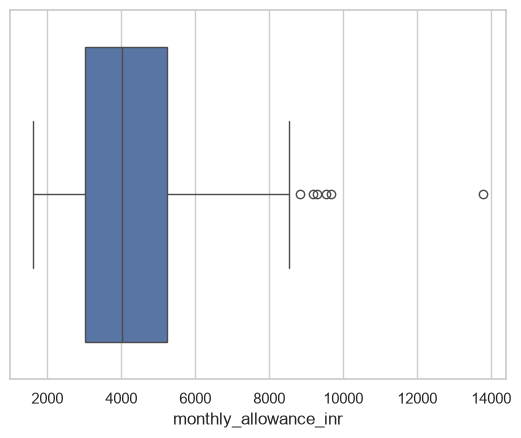

In [6]:
sns.boxplot(data=df,x="monthly_allowance_inr")
plt.show

**Why is "mode" barely useful above?** Continuous measurements (like `exam_score`, rounded to two
decimal places) almost never repeat exactly, so the "most common value" is often just an
arbitrary tie-breaker rather than a meaningful typical value. Mode shines instead on **categorical
or discrete** data, where repeated exact values are the norm:

In [7]:
df[FEATURES].median()

exam_score                 72.150
monthly_allowance_inr    4015.000
quiz_score                 14.625
weekly_study_hours          6.315
dtype: float64

### When mean and median disagree: the outlier effect

The clearest way to see the mean's sensitivity to outliers is to watch what happens when we add a
single extreme value. Take `monthly_allowance_inr`, our right-skewed feature: suppose one student
receives a one-time scholarship payout of ₹150,000 that month. We'll add this one hypothetical
value to a **copy** of the data and compare.

<Axes: xlabel='monthly_allowance_inr'>

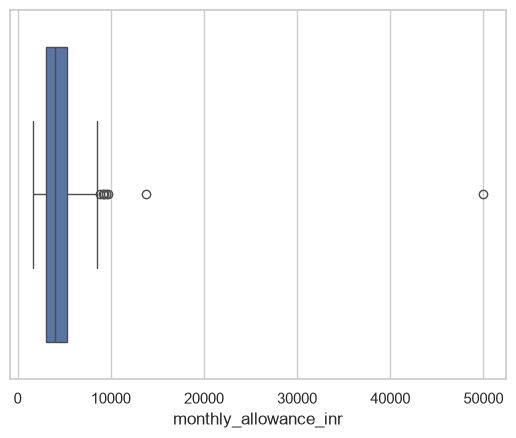

In [12]:
# Demonstrate outlier sensitivity: mean vs. median on monthly_allowance_inr
df.loc[len(df)]=[101, 45, 50000, 78, 20, "Java"]
sns.boxplot(data=df, x="monthly_allowance_inr")

In [8]:
df[FEATURES].mean()


exam_score                 71.931
monthly_allowance_inr    4414.375
quiz_score                 14.035
weekly_study_hours         10.667
dtype: float64

In [9]:

df[FEATURES].median()

exam_score                 72.150
monthly_allowance_inr    4015.000
quiz_score                 14.625
weekly_study_hours          6.315
dtype: float64

**Interpretation:** a single unusual value dragged the mean sharply upward, but the median barely
moved, because the median only depends on which value sits in the middle position — and adding one
extra point far out in the tail doesn't change *what's in the middle*. This is exactly why the
median is described as **robust** to outliers, and why right-skewed data (like income, prices, or
allowances) is usually summarized with a median rather than a mean in real reporting.

Note that `monthly_allowance_inr` and `quiz_score` already show mean and median pulling apart even
*without* an artificial outlier — that's the natural fingerprint of skewness, which we'll quantify
precisely in Section 4.

## 3. Measures of Dispersion

Central tendency tells us where the "middle" of the data is, but says nothing about how **spread
out** the values are around that middle. Two features can have the same mean and look completely
different. Three common measures of spread:

- **Variance**: the average of the squared deviations from the mean. Squaring guarantees a
  non-negative measure and gives larger deviations disproportionately more weight, but it also
  changes the *units* (e.g., "score points squared"), which makes variance hard to interpret
  directly.
- **Standard deviation**: simply the square root of the variance. This brings the units back to
  the original scale (e.g., "score points"), which is why standard deviation — not variance — is
  the number people usually quote and interpret ("scores typically fall within about 8 points of
  the mean").
- **Interquartile range (IQR)**: the range covered by the middle 50% of the data (`Q3 - Q1`). Like
  the median, it ignores the extreme tails entirely, so it is **robust to outliers** in the same
  way the median is — a useful pairing when your central tendency measure is also the median.

**When to prefer which:** use standard deviation alongside the mean for roughly symmetric,
outlier-free data (it's the natural companion in that setting); use IQR alongside the median when
the data is skewed or has outliers, since both are computed only from ranked positions and stay
stable even if the tails stretch further.

### Manual calculation, step by step

Before relying on built-in functions, let's calculate the variance and standard deviation of
`exam_score` by hand, following the definition directly:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

(We divide by `n - 1`, not `n` — this is the *sample* variance formula, which corrects a slight
downward bias that occurs when the mean itself is estimated from the same sample. `pandas` and
`numpy`'s `ddof=1` option use this convention by default in `.var()`/`.std()`.)

In [10]:
# --- Manual, step-by-step variance & standard deviation for exam_score ---
x = df["exam_score"].values
n_obs = len(x)
mean=(x.sum())/n_obs
s=(x-mean)**2
var=s.sum()/(n_obs-1)
std=var**.5
print("Manual var", var)
print("Manual std", std)
print(df["exam_score"].var())

Manual var 58.64453726022013
Manual std 7.657972137597533
58.64453726022013


## IQR — Interquartile Range

IQR measures the spread of the middle 50% of the data.

$$ \boxed{IQR=Q_3-Q_1} $$

where:

Q1= 25th percentile
Q2= 50th percentile (median)
Q3 = 75th percentile

In [17]:
q1=df["monthly_allowance_inr"].quantile(0.25)
q2=df["monthly_allowance_inr"].quantile(0.50)
q3=df["monthly_allowance_inr"].quantile(0.75)
IQR=q3-q1
l=q1-1.5*IQR
u=q3+1.5*IQR
print("q1", q1)
print("q2", q2)
print("q3", q3)
print("IQR", IQR)
print("Lower limit", l)
print("Upper limit", u)
outliers=((df["monthly_allowance_inr"]<l)|(df["monthly_allowance_inr"]>u))
print(outliers)

q1 3020.0
q2 4030.0
q3 5260.0
IQR 2240.0
Lower limit -340.0
Upper limit 8620.0
0      False
1      False
2      False
3       True
4      False
       ...  
156    False
157    False
158     True
159    False
160     True
Name: monthly_allowance_inr, Length: 161, dtype: bool


In [18]:
df=df[~outliers].copy()
df.head()

,student_id,exam_score,monthly_allowance_inr,quiz_score,weekly_study_hours,preferred_language
0,S001,68.85,4180.0,12.89,5.16,Java
1,S002,62.20,5110.0,14.60,6.09,Python
2,S003,74.49,2900.0,14.78,5.72,Python
4,S005,73.60,2690.0,16.03,3.81,Java
5,S006,76.93,2480.0,15.07,5.71,Python


**Reading this table:** notice `monthly_allowance_inr` has a huge variance/std simply because it is
measured in rupees on a much larger numeric scale than, say, `quiz_score` out of 20 — variance and
standard deviation are **not comparable across features with different units or scales** without
standardizing first (we'll do this in Section 5 for the box plot comparison). IQR has the same
scale issue, but within a single skewed feature it remains a more trustworthy "typical spread"
than variance/std, since it isn't inflated by the long tail the way squared deviations are.

## 4. Measures of Distribution Shape

Central tendency and dispersion tell us "where" and "how spread out," but not "what shape." Two
features can share the same mean and standard deviation while looking completely different when
plotted. Skewness and kurtosis quantify shape numerically.

- **Skewness** measures asymmetry — which side has the longer tail.
  - Skewness **≈ 0**: roughly symmetric (like a normal distribution).
  - Skewness **> 0** (right/positive skew): a long tail stretches to the **right**; typically
    `mean > median` because a few large values pull the mean upward.
  - Skewness **< 0** (left/negative skew): a long tail stretches to the **left**; typically
    `mean < median` because a few small values pull the mean downward.

- **Kurtosis** (we use *excess* kurtosis, i.e. relative to the normal distribution's value of 0)
  measures tail heaviness and peak sharpness.
  - Excess kurtosis **≈ 0** (mesokurtic): tails behave like a normal distribution.
  - Excess kurtosis **> 0** (leptokurtic): heavier tails and/or a sharper peak than normal — more
    extreme outliers than you'd expect from a normal curve.
  - Excess kurtosis **< 0** (platykurtic): lighter tails and a flatter, more spread-out peak — data
    is more "spread across the middle" than a normal curve, which is exactly what a **bimodal**
    distribution tends to look like (probability mass pulled away from the center into two humps).

Together, skewness and kurtosis are a quick numerical check for **departures from normality** —
useful because many classical statistical methods (t-tests, linear regression, etc.) assume
approximately normal data.

**Tying this back to how we designed the data:**

- `exam_score` was built to be approximately normal, and indeed its skewness and excess kurtosis
  both sit close to 0.
- `monthly_allowance_inr` was built right-skewed (lognormal), which shows up as clearly positive
  skewness — consistent with the mean sitting above the median we saw in Section 2.
- `quiz_score` was built left-skewed (a ceiling effect where most students score high), and its
  skewness comes out negative, matching `mean < median` from Section 2.
- `weekly_study_hours` was built as a **mixture of two groups** (bimodal). Its skewness is modest,
  but notice the **negative excess kurtosis** — this is the classic numeric signature of a
  flatter-than-normal, two-humped shape. This is also a great cautionary example: **skewness and
  kurtosis alone cannot conclusively prove a distribution is bimodal** — a low/negative kurtosis is
  a hint, but only a histogram (Section 5) actually *shows* the two humps directly. Summary
  statistics can point you in the right direction, but they can also hide structure that only a
  picture reveals.

## Distribution of exam_score


In [21]:
print(df["exam_score"].skew())
print(df["exam_score"].kurt())

0.118261669278241
0.187599823037488


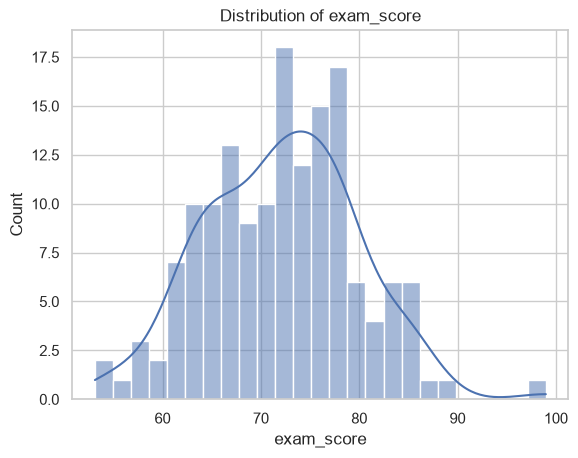

In [23]:
sns.histplot(data=df, x="exam_score", bins=25, kde=True)
plt.title("Distribution of exam_score")
plt.show()

## Distribution of monthly_allowance_inr

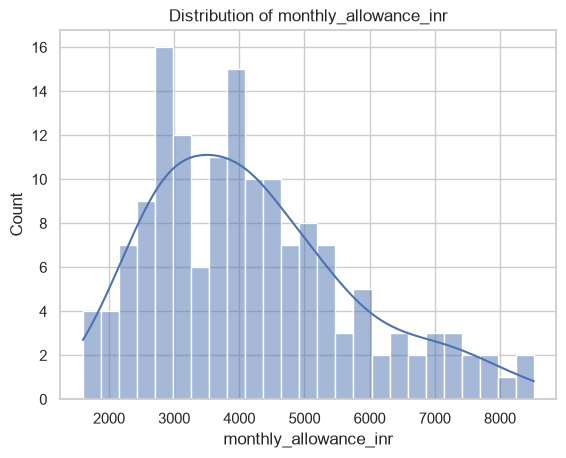

In [24]:
sns.histplot(data=df, x="monthly_allowance_inr", bins=25, kde=True)
plt.title("Distribution of monthly_allowance_inr")
plt.show()

## Distribution of quiz_score

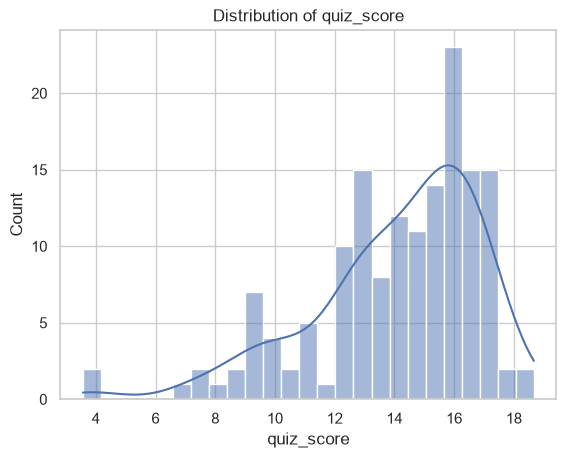

In [25]:
sns.histplot(data=df, x="quiz_score", bins=25, kde=True)
plt.title("Distribution of quiz_score")
plt.show()

## Distribution of weekly_study_hours

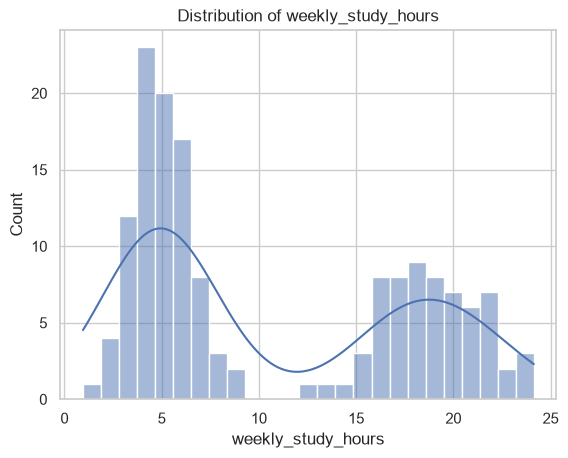

In [26]:
sns.histplot(data=df, x="weekly_study_hours", bins=25, kde=True)
plt.title("Distribution of weekly_study_hours")
plt.show()

## 5. Data Visualizations

Numbers alone can mislead — this is sometimes called "Anscombe's quartet problem," where wildly
different-looking datasets share identical means, variances, and correlations. Visualizations let
us confirm (or challenge) what the summary statistics suggested, and they reveal structure — like
the bimodal split in `weekly_study_hours` — that a single number cannot.

**Insight this gives that raw numbers can't:** you can *see* exactly how mean and median relate to
each tail — for `monthly_allowance_inr`, the mean is visibly pulled right of the median by the long
tail of high earners; for `quiz_score`, it's pulled left. For `weekly_study_hours`, the mean and
median both land in the empty "valley" between the two humps — a value that hardly any actual
student has. This is the single clearest illustration in the whole notebook of why a central
tendency number can be actively misleading without a picture to check it against.

### 5.1 Box plots

A box plot summarizes five numbers at once: the minimum (within 1.5×IQR of Q1), Q1 (25th
percentile), the median (Q2, 50th percentile), Q3 (75th percentile), and the maximum (within
1.5×IQR of Q3) — with any points beyond that range flagged as individual outlier dots. It's a
compact way to compare spread and skewness *across several features at once*, which a table of
numbers makes you compare column by column.

Because our four features live on very different scales (₹ vs. hours vs. a 0-100 score vs. a 0-20
score), we standardize each feature to a common z-score scale (mean 0, standard deviation 1) purely
for this side-by-side comparison — standardizing preserves each feature's *shape* while making the
spreads visually comparable.

**Insight this gives that raw numbers can't:** side-by-side boxes make skewness visible as an
*asymmetric* box — notice how `monthly_allowance_inr`'s box and whisker stretch much further above
the median than below it (right-skew), the mirror image for `quiz_score`, and how
`monthly_allowance_inr` shows individual outlier dots above the top whisker, flagging the same
"a few students earn a lot more" pattern we quantified with skewness in Section 4 — but now you can
see exactly how many outliers there are and how extreme each one is, which a single skewness number
cannot show.

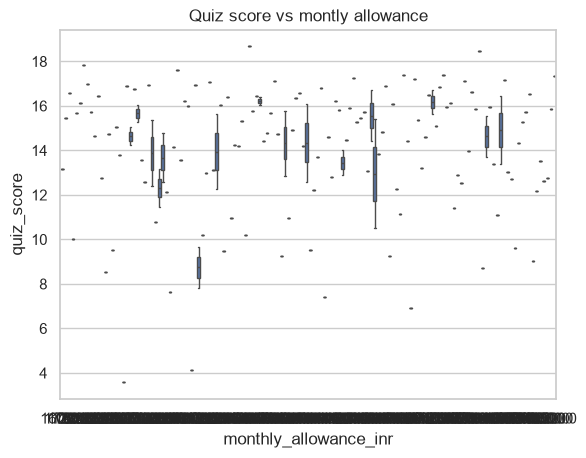

In [31]:
sns.boxplot(data=df, x="monthly_allowance_inr", y="")
plt.title("Quiz score vs montly allowance")
plt.show()

### 5.2 Scatter plots

Scatter plots reveal **relationships between two features** — something no single-feature
statistic (mean, std, skewness, etc.) can show at all, no matter how many of them you compute. We
show one pair with a clear relationship and one pair with essentially none, so you can compare what
"a real pattern" looks like against "no pattern" side by side.

## quiz_score vs exam_score

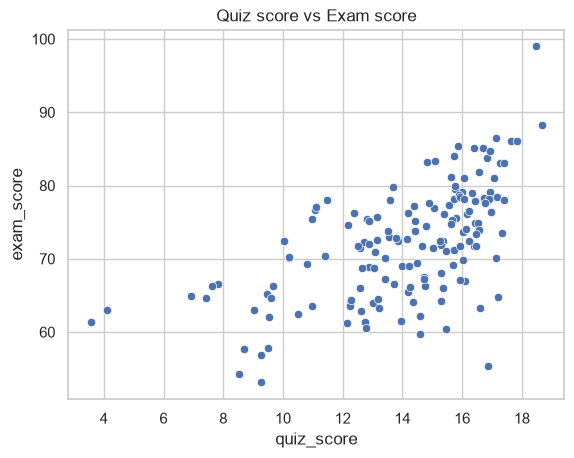

In [27]:
sns.scatterplot(data=df, x="quiz_score", y="exam_score")
plt.title("Quiz score vs Exam score")
plt.show()

## quiz_score vs monthly_allowance_inr

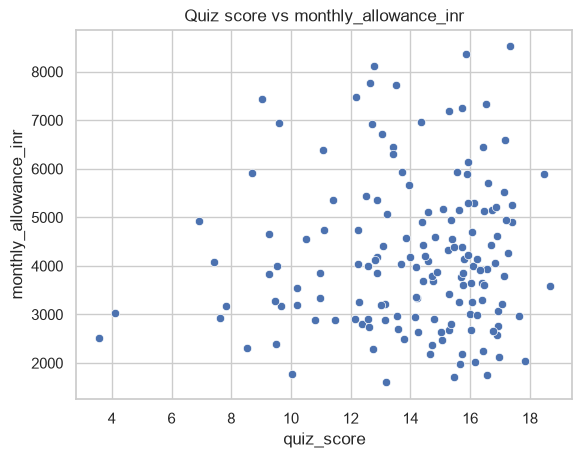

In [32]:
sns.scatterplot(data=df, x="quiz_score", y="monthly_allowance_inr")
plt.title("Quiz score vs monthly_allowance_inr")
plt.show()

### Pearson Correlation Coefficient

The **Pearson correlation coefficient** measures the strength and direction of the linear relationship between two numerical variables, $X$ and $Y$.

The formula is:

$$
\boxed{
r =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
}
}
$$

where:

- $r$ = Pearson correlation coefficient
- $x_i$ = individual observation of variable $X$
- $y_i$ = individual observation of variable $Y$
- $\bar{x}$ = mean of variable $X$
- $\bar{y}$ = mean of variable $Y$
- $n$ = number of observations

The Pearson correlation coefficient always lies between:

$$
\boxed{-1 \leq r \leq +1}
$$

### Interpretation of Correlation Values

| Correlation ($r$) | Interpretation |
|---:|---|
| $+1.00$ | Perfect positive correlation |
| $+0.70$ to $+0.99$ | Strong positive correlation |
| $+0.30$ to $+0.69$ | Moderate positive correlation |
| $-0.29$ to $+0.29$ | Weak or little linear correlation |
| $-0.30$ to $-0.69$ | Moderate negative correlation |
| $-0.70$ to $-0.99$ | Strong negative correlation |
| $-1.00$ | Perfect negative correlation |

### Direction of Correlation

**Positive correlation:**

$$
X\uparrow \Rightarrow Y\uparrow
$$

As $X$ increases, $Y$ tends to increase.

**Negative correlation:**

$$
X\uparrow \Rightarrow Y\downarrow
$$

As $X$ increases, $Y$ tends to decrease.

**No linear correlation:**

$$
r\approx0
$$

There is little or no **linear** relationship between $X$ and $Y$.

### Example

Suppose:

$$
r(\text{quiz score},\text{exam score})=0.82
$$

This indicates a **strong positive linear relationship** between quiz score and exam score. Students with higher quiz scores tend to have higher exam scores.

### Important Points

1. **Correlation does not imply causation.**  
   A strong correlation does not prove that one variable causes changes in another.

2. **Pearson correlation measures linear relationships.**  
   A correlation close to zero does not necessarily mean that there is no relationship. The variables may have a strong nonlinear relationship.

3. **Outliers can affect Pearson correlation.**  
   Therefore, a scatter plot should be examined before interpreting the correlation coefficient.

4. **Only appropriate numerical variables should be included.**  
   Identifier columns such as `student_id` and categorical variables such as `preferred_language` should not be directly included in a Pearson correlation matrix.

### Key Takeaway

> **A correlation heatmap provides a quick visual summary of the direction and strength of linear relationships among numerical variables. Pearson correlation quantifies this relationship on a scale from $-1$ to $+1$.**

## Pearson Correlation  quiz_score vs exam_score

In [33]:
correlation=df["quiz_score"].corr(df["exam_score"])
print("Pearson Correlation: ", correlation)

Pearson Correlation:  0.5972934219432382


## Pearson Correlation  quiz_score vs monthly_allowance_inr

In [34]:
correlation=df["quiz_score"].corr(df["monthly_allowance_inr"])
print("Pearson Correlation: ", correlation)

Pearson Correlation:  0.05467747416743239


## Correlation Heatmap

A **correlation heatmap** is a graphical representation of the correlation matrix. It uses colors and numerical values to show the **strength and direction of the linear relationship** between pairs of numerical variables.


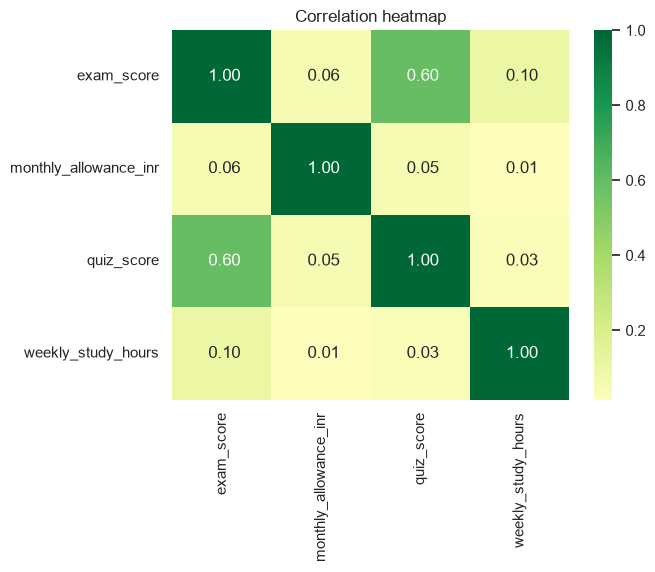

In [35]:
numeric_df=df.select_dtypes(include="number")
corr=numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=" .2f")
plt.title("Correlation heatmap")
plt.show()